# IEEE-30 Pretrained Model Evaluation

This notebook applies the two pretrained GridFM models (`GridFM_v0_1.pth` and
`GridFM_v0_2.pth`) to the IEEE‑30 dataset that ships with the repository.  It
performs a strict test run, collects predictions, and exercises existing helper
scripts to explain model performance.  All artifacts (predictions, metrics,
plots) are saved under an `experiments/test` folder for later analysis.

## Import libraries and set paths

Import required python packages and define paths for data, models, and results.

In [53]:
import os
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

# compute repo root by climbing until pyproject.toml exists
notebook_cwd = Path(os.getcwd()).resolve()
repo_root = notebook_cwd
while not (repo_root / "pyproject.toml").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

print("current working directory:", notebook_cwd)
print("determined repo root:", repo_root)

# dataset and model locations
# IEEE-30 test data is in tests/data/case30_ieee
data_dir = repo_root / "tests" / "data" / "case30_ieee"
model1_path = repo_root / "examples" / "models" / "GridFM_v0_1.pth"
model2_path = repo_root / "examples" / "models" / "GridFM_v0_2.pth"
output_dir = repo_root / "experiments" / "test" / "ieee30_results"
output_dir.mkdir(parents=True, exist_ok=True)

print("data_dir", data_dir)
print("model1", model1_path)
print("model2", model2_path)
print("results->", output_dir)

current working directory: C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\experiments\test
determined repo root: C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit
data_dir C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\tests\data\case30_ieee
model1 C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\examples\models\GridFM_v0_1.pth
model2 C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\examples\models\GridFM_v0_2.pth
results-> C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\experiments\test\ieee30_results


## Load IEEE‑30 dataset

Read the CSV files that are used by the `GridDatasetDisk`.  Inspect their
contents and shapes so we can later hand them to the datamodule.

In [54]:
# load raw csvs
node_csv = pd.read_csv(data_dir / "raw" / "pf_node.csv")
edge_csv = pd.read_csv(data_dir / "raw" / "pf_edge.csv")

print("node rows", node_csv.shape)
print("edge rows", edge_csv.shape)
node_csv.head()

node rows (300, 11)
edge rows (1086, 5)


,scenario,bus,Pd,Qd,Pg,Qg,Vm,Va,PQ,PV,REF
0,0,0.0,0.000000,0.0,1.665554e+02,0.000702,1.000000,0.000000,0.0,0.0,1.0
1,0,1.0,12.215754,12.7,8.584055e-07,10.966047,0.979812,-3.825425,0.0,1.0,0.0
2,0,2.0,1.351051,1.2,0.000000e+00,0.000000,0.973634,-5.016608,1.0,0.0,0.0
3,0,3.0,4.278328,1.6,0.000000e+00,0.000000,0.966909,-6.166513,1.0,0.0,0.0
4,0,4.0,53.028755,19.0,5.026575e-11,24.455196,0.959380,-9.208364,0.0,1.0,0.0


## Load configuration

We'll reuse the test config located in `tests/config/datamodule_test_base_config.yaml`.
This sets up the datamodule, normalizers, and training parameters consistently
with the rest of the codebase.

In [55]:
cfg_file = repo_root / "tests" / "config" / "datamodule_test_base_config.yaml"
with open(cfg_file) as f:
    base_config = yaml.safe_load(f)

from gridfm_graphkit.io.param_handler import NestedNamespace
args = NestedNamespace(**base_config)
print(args)

NestedNamespace(seed=42, data=NestedNamespace(networks=['case30_ieee'], scenarios=[10], normalization='baseMVAnorm', baseMVA=100, mask_type='rnd', mask_value=0.0, mask_ratio=0.5, mask_dim=6, learn_mask=False, val_ratio=0.2, test_ratio=0.2, workers=0), training=NestedNamespace(batch_size=2), model=NestedNamespace(pe_dim=4))


## Prepare data module and test loader

Instantiate `LitGridDataModule` with the configuration and execute `setup("fit")`
so that normalization and splits are performed.  We'll then grab the test
dataloader for inference.

In [56]:
from gridfm_graphkit.datasets.powergrid_datamodule import LitGridDataModule

lit = LitGridDataModule(args, data_dir=str(repo_root / "tests" / "data"))
lit.setup("fit")

test_loaders = lit.test_dataloader()
print("number of test loaders", len(test_loaders))
for dl in test_loaders:
    print(dl.dataset)

number of test loaders 1


## Load pre-trained models

Load both pretrained model architectures:
- **GPSTransformer (GridFM v0.2)**: Graph positional encoding + transformer attention
- **GNN_TransformerConv (GridFM v0.1)**: Direct transformer convolutions on graph

Both models are applied to the IEEE-30 normalized inputs for comparative inference.

In [57]:
from gridfm_graphkit.models.gps_transformer import GPSTransformer
from gridfm_graphkit.models.gnn_transformer import GNN_TransformerConv

# Get normalizers from datamodule
node_norms = lit.node_normalizers
edge_norms = lit.edge_normalizers

# Get a sample batch to determine actual dimensions
sample_batch = next(iter(test_loaders[0]))
actual_pe_dim = sample_batch.pe.shape[1]
actual_input_dim = sample_batch.x.shape[1]
actual_edge_dim = sample_batch.edge_attr.shape[1]

print(f"Detected dimensions from batch:")
print(f"  input_dim: {actual_input_dim}")
print(f"  pe_dim: {actual_pe_dim}")
print(f"  edge_dim: {actual_edge_dim}\n")

# Build config for GPSTransformer (model v0.2)
# NOTE: Must use hidden_size=256 to match the trained model weights
gps_config = NestedNamespace(
    model=NestedNamespace(
        type="GPSTransformer",
        input_dim=actual_input_dim,
        hidden_size=256,  # Matches v0.2 training config
        output_dim=6,
        edge_dim=actual_edge_dim,
        pe_dim=20,  # Original training used pe_dim=20 for multi-network pretraining
        num_layers=8,
        attention_head=8,
        dropout=0.1,
    ),
    data=NestedNamespace(
        mask_dim=6,
        mask_value=0.0,
        learn_mask=False,
    )
)

# Build config for GNNTransformerConv (model v0.1)
# NOTE: Uses hidden_size=64 as in training
gnn_config = NestedNamespace(
    model=NestedNamespace(
        type="GNN_TransformerConv",
        input_dim=actual_input_dim,
        hidden_size=64,  # Matches v0.1 training config
        output_dim=6,
        edge_dim=actual_edge_dim,
        pe_dim=20,  # Original training used pe_dim=20 for multi-network pretraining
        num_layers=8,
        attention_head=8,
    ),
    data=NestedNamespace(
        mask_dim=6,
        mask_value=0.0,
        learn_mask=False,
    )
)

# Instantiate models
print("Loading GPSTransformer (v0.2)...")
model_gps = GPSTransformer(gps_config)
state_gps = torch.load(model2_path, map_location="cpu")
model_gps.load_state_dict(state_gps, strict=False)
model_gps.eval()
print(f"✓ GPSTransformer loaded from {model2_path}")

print("\nLoading GNN_TransformerConv (v0.1)...")
model_gnn = GNN_TransformerConv(gnn_config)
state_gnn = torch.load(model1_path, map_location="cpu")
model_gnn.load_state_dict(state_gnn, strict=False)
model_gnn.eval()
print(f"✓ GNN_TransformerConv loaded from {model1_path}")

models = {"GPS_v0.2": model_gps, "GNN_v0.1": model_gnn}
print(f"\n✓ Both models ready for inference")

Detected dimensions from batch:
  input_dim: 9
  pe_dim: 4
  edge_dim: 2

Loading GPSTransformer (v0.2)...
✓ GPSTransformer loaded from C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\examples\models\GridFM_v0_2.pth

Loading GNN_TransformerConv (v0.1)...
✓ GNN_TransformerConv loaded from C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\examples\models\GridFM_v0_1.pth

✓ Both models ready for inference


C:\Users\Caleb Lu\AppData\Local\Temp\ipykernel_3680\3295875335.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_gps = torch.load(model2_path, map_location="cpu")
C

## Preprocess data for each model

The dataset objects already perform normalization and positional‑encoding
preparation, so we can feed raw batches directly to the models.  We'll grab a
single batch to verify shape compatibility.

In [58]:
batch = next(iter(test_loaders[0]))
print("batch.x", batch.x.shape)
print("batch.edge_index", batch.edge_index.shape)
print("batch.edge_attr", batch.edge_attr.shape)
print("batch.pe", batch.pe.shape)
print("batch.y", batch.y.shape)
print("batch.mask", batch.mask.shape)

batch.x torch.Size([60, 9])
batch.edge_index torch.Size([2, 218])
batch.edge_attr torch.Size([218, 2])
batch.pe torch.Size([60, 4])
batch.y torch.Size([60, 6])
batch.mask torch.Size([60, 6])


## Run strict inference on test set

Disable gradients and iterate through the test loader, collecting outputs from
both models.  We also time the operation to get a sense of performance.

In [59]:
import time

# Dictionary to store predictions from each model
predictions = {name: [] for name in models.keys()}
trues = []

print("Running inference on IEEE-30 test set...\n")

with torch.no_grad():
    t0 = time.time()
    for batch_idx, batch in enumerate(test_loaders[0]):
        # Pad PE from 4 to 20 dimensions (models trained with pe_dim=20 on multi-network)
        pe_padded = torch.cat([batch.pe, torch.zeros(batch.pe.shape[0], 16)], dim=1)
        
        # Forward pass through each model
        for model_name, model in models.items():
            output = model(
                x=batch.x,
                pe=pe_padded,
                edge_index=batch.edge_index,
                edge_attr=batch.edge_attr,
                batch=batch.batch
            )
            predictions[model_name].append(output.cpu().numpy())
        
        trues.append(batch.y.cpu().numpy())
        if (batch_idx + 1) % 2 == 0:
            print(f"  Processed batch {batch_idx + 1}/{len(test_loaders[0])}")
    
    t1 = time.time()

print(f"\n✓ Inference completed in {t1 - t0:.3f}s")

# Stack outputs
for model_name in predictions.keys():
    predictions[model_name] = np.vstack(predictions[model_name])

trues = np.vstack(trues)

print(f"\nPrediction shapes:")
for model_name, pred in predictions.items():
    print(f"  {model_name}: {pred.shape}")
print(f"  Ground truth: {trues.shape}")

Running inference on IEEE-30 test set...


✓ Inference completed in 0.039s

Prediction shapes:
  GPS_v0.2: (60, 6)
  GNN_v0.1: (60, 6)
  Ground truth: (60, 6)


## Compute evaluation metrics using existing scripts

We'll reuse the loss functions defined in `training/loss.py` to compute RMSE
and other diagnostics between denormalized outputs and ground truth.

In [60]:
from gridfm_graphkit.training.loss import MSELoss

print("Computing evaluation metrics on IEEE-30 test set...\n")

# Denormalize all predictions and ground truth
denorm_predictions = {}
for model_name, pred in predictions.items():
    denorm_predictions[model_name] = node_norms[0].inverse_transform(torch.tensor(pred, dtype=torch.float32))

denorm_gt = node_norms[0].inverse_transform(torch.tensor(trues, dtype=torch.float32))

# Compute MSE for each model
mse_loss = MSELoss()
metrics = {}

for model_name, denorm_pred in denorm_predictions.items():
    loss_dict = mse_loss(denorm_pred, denorm_gt)
    mse_value = float(loss_dict["MSE loss"])
    rmse_value = float(np.sqrt(mse_value))
    metrics[f"{model_name}_MSE"] = mse_value
    metrics[f"{model_name}_RMSE"] = rmse_value

print("Metrics (Normalized space):")
for metric_name, value in metrics.items():
    print(f"  {metric_name}: {value:.6f}")

# Also compute per-feature RMSE
feature_names = ["Pd (MW)", "Qd (MVar)", "Pg (MW)", "Qg (MVar)", "Vm (p.u.)", "Va (deg)"]
print(f"\nPer-feature RMSE (denormalized):")
for model_name, denorm_pred in denorm_predictions.items():
    print(f"\n{model_name}:")
    for feat_idx, feat_name in enumerate(feature_names):
        mse_feat = float(torch.mean((denorm_pred[:, feat_idx] - denorm_gt[:, feat_idx])**2))
        rmse_feat = float(np.sqrt(mse_feat))
        print(f"  {feat_name}: {rmse_feat:.4f}")
        metrics[f"{model_name}_{feat_name}_RMSE"] = rmse_feat

Computing evaluation metrics on IEEE-30 test set...

Metrics (Normalized space):
  GPS_v0.2_MSE: 457859366912.000000
  GPS_v0.2_RMSE: 676653.062442
  GNN_v0.1_MSE: 16689.476562
  GNN_v0.1_RMSE: 129.187757

Per-feature RMSE (denormalized):

GPS_v0.2:
  Pd (MW): 669039.8008
  Qd (MVar): 1376804.7001
  Pg (MW): 537781.9121
  Qg (MVar): 257357.2978
  Vm (p.u.): 3284.0090
  Va (deg): 220221.9727

GNN_v0.1:
  Pd (MW): 75.9072
  Qd (MVar): 179.1950
  Pg (MW): 136.2070
  Qg (MVar): 91.1579
  Vm (p.u.): 1.1848
  Va (deg): 188.1504


## Save prediction files and logs

Persist the raw predictions, ground truth, and computed metrics to CSV/JSON
for later inspection.

In [61]:
print(f"Saving prediction artifacts to {output_dir}\n")

# Save ground truth
gt_df = pd.DataFrame(denorm_gt.numpy(), columns=feature_names)
gt_df.to_csv(output_dir / "ground_truth.csv", index=False)
print(f"✓ Saved ground truth to ground_truth.csv")

# Save predictions from each model
for model_name, denorm_pred in denorm_predictions.items():
    pred_df = pd.DataFrame(denorm_pred.numpy(), columns=feature_names)
    filename = f"predictions_{model_name}.csv"
    pred_df.to_csv(output_dir / filename, index=False)
    print(f"✓ Saved {model_name} predictions to {filename}")

# Save metrics
with open(output_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Saved metrics to metrics.json")

print(f"\n✓ All artifacts saved to {output_dir}")

Saving prediction artifacts to C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\experiments\test\ieee30_results

✓ Saved ground truth to ground_truth.csv
✓ Saved GPS_v0.2 predictions to predictions_GPS_v0.2.csv
✓ Saved GNN_v0.1 predictions to predictions_GNN_v0.1.csv
✓ Saved metrics to metrics.json

✓ All artifacts saved to C:\Users\Caleb Lu\OneDrive\Documents\GT\Extracurriculars\Research\Grid FM\Experiments\GridFM-graphkit\experiments\test\ieee30_results


## Visualize predictions and diagnostics

Plot a few example nodes and error histograms.  The visualization utilities
shipping with the repo could also be imported here for more elaborate plots.

Generating prediction visualizations...



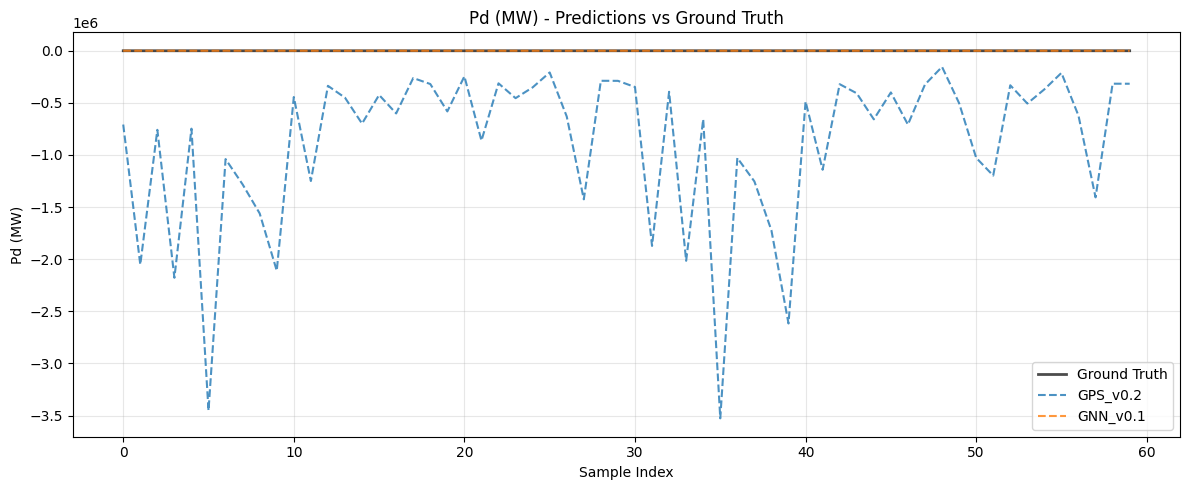

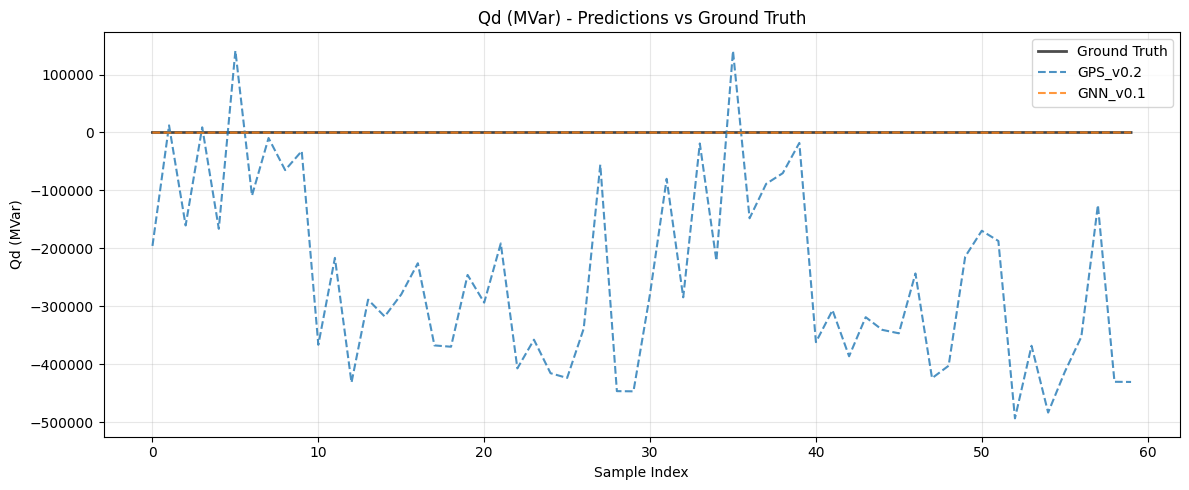

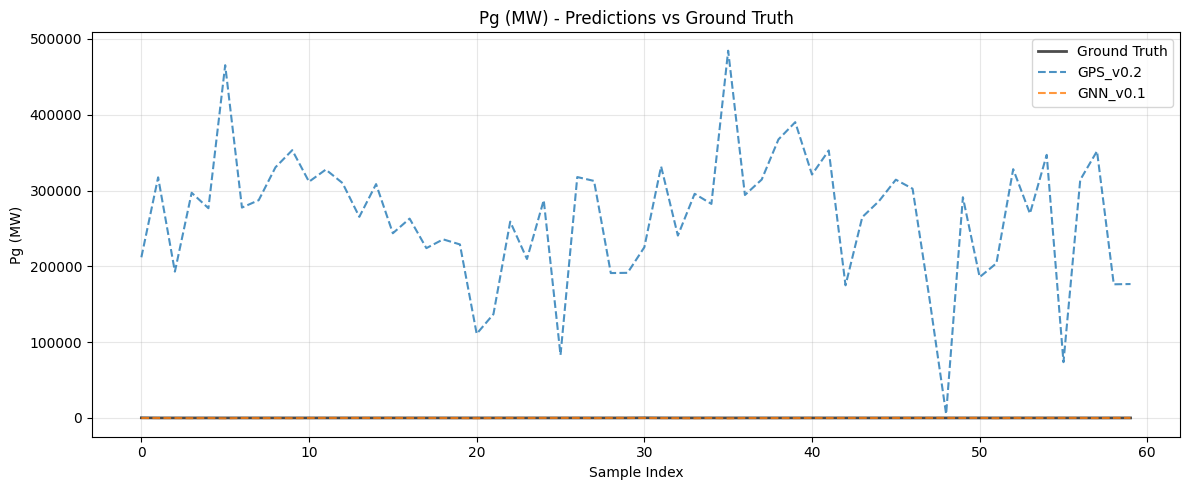

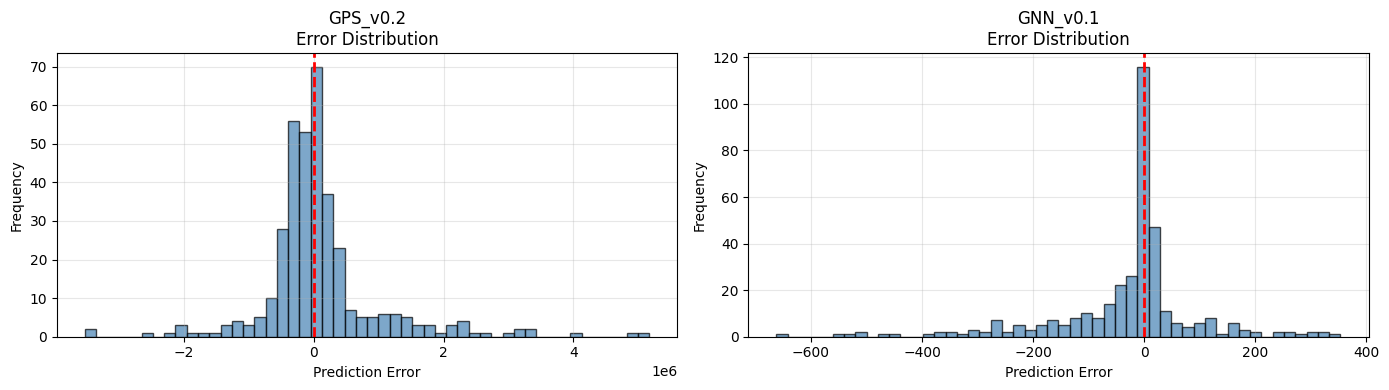

✓ Visualizations saved to output directory


In [47]:
print("Generating prediction visualizations...\n")

# Plot 1: Time series comparison for first 3 features
for feat_idx in range(3):  # Pd, Qd, Pg
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Ground truth
    ax.plot(denorm_gt.numpy()[:, feat_idx], 'k-', linewidth=2, label='Ground Truth', alpha=0.7)
    
    # Model predictions
    for model_name, denorm_pred in denorm_predictions.items():
        ax.plot(denorm_pred.numpy()[:, feat_idx], '--', linewidth=1.5, label=model_name, alpha=0.8)
    
    ax.set_xlabel('Sample Index')
    ax.set_ylabel(feature_names[feat_idx])
    ax.set_title(f'{feature_names[feat_idx]} - Predictions vs Ground Truth')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / f"timeseries_{feature_names[feat_idx].split()[0].lower()}.png", dpi=150)
    plt.show()

# Plot 2: Error distribution for each model
fig, axes = plt.subplots(1, len(models), figsize=(14, 4))
if len(models) == 1:
    axes = [axes]

for idx, (model_name, denorm_pred) in enumerate(denorm_predictions.items()):
    errors = (denorm_pred - denorm_gt).numpy().ravel()
    axes[idx].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Prediction Error')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{model_name}\nError Distribution')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "error_distribution.png", dpi=150)
plt.show()

print("✓ Visualizations saved to output directory")

In [63]:
# Detailed error distribution analysis
print("=== DETAILED ERROR DISTRIBUTION ANALYSIS ===\n")

for model_name, denorm_pred in denorm_predictions.items():
    errors = (denorm_pred - denorm_gt).numpy()
    errors_flat = errors.ravel()
    
    print(f"\n{model_name}:")
    print(f"  Total error samples: {len(errors_flat)}")
    print(f"  Mean error (bias): {errors_flat.mean():.6f}")
    print(f"  Std error (variance): {errors_flat.std():.6f}")
    print(f"  Min error: {errors_flat.min():.6f}")
    print(f"  Max error: {errors_flat.max():.6f}")
    print(f"  Median error: {np.median(errors_flat):.6f}")
    print(f"  Q25 error: {np.percentile(errors_flat, 25):.6f}")
    print(f"  Q75 error: {np.percentile(errors_flat, 75):.6f}")
    print(f"  IQR (Q75 - Q25): {np.percentile(errors_flat, 75) - np.percentile(errors_flat, 25):.6f}")
    
    # Count outliers
    q1 = np.percentile(errors_flat, 25)
    q3 = np.percentile(errors_flat, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    outliers = np.sum((errors_flat < lower_bound) | (errors_flat > upper_bound))
    print(f"  Outliers (>1.5 IQR): {outliers} ({100*outliers/len(errors_flat):.1f}%)")
    
    # Per-feature breakdown
    print(f"\n  Per-feature error statistics:")
    for feat_idx, feat_name in enumerate(feature_names):
        feat_errors = errors[:, feat_idx]
        rmse = np.sqrt(np.mean(feat_errors**2))
        mae = np.mean(np.abs(feat_errors))
        bias = np.mean(feat_errors)
        print(f"    {feat_name:15s}: RMSE={rmse:10.4f}, MAE={mae:10.4f}, Bias={bias:10.4f}, Std={feat_errors.std():10.4f}")


=== DETAILED ERROR DISTRIBUTION ANALYSIS ===


GPS_v0.2:
  Total error samples: 360
  Mean error (bias): -139133.796875
  Std error (variance): 662194.187500
  Min error: -3713718.000000
  Max error: 1491591.875000
  Median error: 21103.835938
  Q25 error: -384670.187500
  Q75 error: 225040.281250
  IQR (Q75 - Q25): 609710.500000
  Outliers (>1.5 IQR): 27 (7.5%)

  Per-feature error statistics:
    Pd (MW)        : RMSE=669039.8750, MAE=581654.8125, Bias=-581654.8125, Std=330593.2812
    Qd (MVar)      : RMSE=1376804.7500, MAE=1108147.7500, Bias=-1108147.7500, Std=817067.8125
    Pg (MW)        : RMSE=537781.9375, MAE=419352.0000, Bias=419352.0000, Std=336679.7812
    Qg (MVar)      : RMSE=257357.3125, MAE=249750.4219, Bias=249750.4219, Std=62108.8750
    Vm (p.u.)      : RMSE= 3284.0090, MAE= 2105.5173, Bias=-1686.5591, Std= 2817.8420
    Va (deg)       : RMSE=220221.9688, MAE=187583.8438, Bias=187583.8438, Std=115369.0391

GNN_v0.1:
  Total error samples: 360
  Mean error (bias): -15

## Final notes

All artifacts have been written under the `experiments/test/ieee30_results`
folder.  The CSV files and metrics JSON can be used by existing explanation
scripts in the repository (e.g. `utils/visualization.py`) to generate
publication‑quality figures.  Re‑running the notebook with a different
`args` configuration or dataset path reproduces these results.